# Experiment Goal

The goal of this experiement is to reproduce the central claim of the the ResNet paper: **deep residual networks are easier to train than plain deep networks**.

We aim to demonstrate the *degradation problem*, where increasing the depth of a standard convolutional neural network leads to **higher training error**, and compare this with residual networks, which use **skip connections** to enable effective training of deeper models.

To achieve this, we will:

* Train **plain CNNs** (without skip connections) at different depths (20 and 56 layers)
* Train **ResNet models** (with residual/skip connections) at the same depths (20 and 56 layers)
* Compare their **training loss, test accuracy, and convergence behavior**

We expect to observe that:

* Deeper **plain networks perform worse** due to optimization difficulties
* Deeper **ResNet models perform better**, confirming that residual learning helps address the degradation problem

All experiments will be conducted on the **CIFAR-10 dataset** in a controlled setting where model depth is the primary variable.

# Imports and Setup

In [1]:
# Imports and Setup

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# For us to be able to reproduce results we use a seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# For deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters

BATCH_SIZE = 128
LEARNING_RATE = 0.1
EPOCHS = 40 # Probably will change this after debugging

# Dataset Path
DATASET_PATH = "../data"

# Function to count the number of parameters in the model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Using device: cuda


# CIFAR-10 Data Loading

100%|██████████| 170M/170M [00:03<00:00, 48.3MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of training samples: 50000
Number of test samples: 10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].


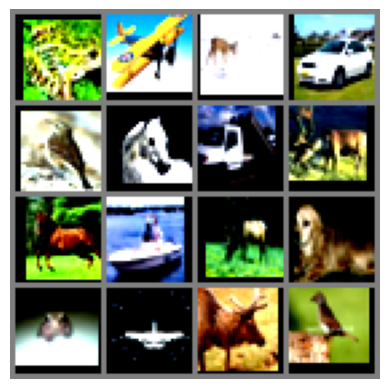

frog  airplane deer  automobile bird  horse truck deer  horse ship  deer  dog   frog  airplane deer  bird 


In [2]:
# CIFAR-10 Dataset and Data Loaders

# Normalization values for CIFAR-10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


# Download and prepare the CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transform)

test_dataset = torchvision.datasets.CIFAR10(root=DATASET_PATH, train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

classes = train_dataset.classes
print(f"Classes: {classes}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

# Visualize some training images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:16], nrow=4))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(16)))

# Model Definitions

In [3]:
# Plain Model (No skip connections)
class PlainBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = F.relu(out)
        return out


# Residual Block (with skip connections)
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity
        out = F.relu(out)

        return out


# Now we make the CIFAR net that uses these blocks.
class CIFARResNet(nn.Module):
    """
    CIFAR-style network builder used for both:
    - plain deep networks (with PlainBlock)
    - residual networks (with ResidualBlock)

    The architecture follows the CIFAR-10 setup from the ResNet paper:
    an initial 3x3 conv, then 3 stages with channel sizes 16, 32, 64,
    followed by global average pooling and a final linear classifier.
    """

    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()

        self.in_channels = 16

        # Initial conv layer for CIFAR-10 images
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(16)

        # Three stages: 32x32 -> 16x16 -> 8x8
        self.layer1 = self._make_layer(
            block, out_channels=16, num_block_layers=num_blocks[0], stride=1
        )
        self.layer2 = self._make_layer(
            block, out_channels=32, num_block_layers=num_blocks[1], stride=2
        )
        self.layer3 = self._make_layer(
            block, out_channels=64, num_block_layers=num_blocks[2], stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, block, out_channels, num_block_layers, stride):
        layers = []

        # First block in the layer may change resolution/channels
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels

        # Remaining blocks keep same shape
        for _ in range(1, num_block_layers):
            layers.append(block(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out

# Factory functions to create specific models based on depth
def make_plain_net(depth):
    """
    Create a plain CNN with depth = 6n + 2.
    Example:
        depth=20 -> n=3
        depth=56 -> n=9
    """
    assert (depth - 2) % 6 == 0, "Depth must satisfy 6n + 2"
    n = (depth - 2) // 6
    return CIFARResNet(PlainBlock, [n, n, n])


def make_resnet(depth):
    """
    Create a ResNet with depth = 6n + 2.
    Example:
        depth=20 -> n=3
        depth=56 -> n=9
    """
    assert (depth - 2) % 6 == 0, "Depth must satisfy 6n + 2"
    n = (depth - 2) // 6
    return CIFARResNet(ResidualBlock, [n, n, n])

plain20 = make_plain_net(20).to(device)
plain56 = make_plain_net(56).to(device)
resnet20 = make_resnet(20).to(device)
resnet56 = make_resnet(56).to(device)

print("Plain-20 params :", count_parameters(plain20))
print("Plain-56 params :", count_parameters(plain56))
print("ResNet-20 params:", count_parameters(resnet20))
print("ResNet-56 params:", count_parameters(resnet56))

Plain-20 params : 269722
Plain-56 params : 853018
ResNet-20 params: 272474
ResNet-56 params: 855770


# Training utilities

In [4]:
# Training and Evaluation Functions


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

In [5]:
def train_model(
    model,
    train_loader,
    test_loader,
    device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=1e-4,
):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=0.9,
        weight_decay=weight_decay,
    )

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[int(0.5 * epochs), int(0.75 * epochs)], gamma=0.1
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "lr": [],
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["lr"].append(current_lr)

        print(
            f"Epoch [{epoch+1:02d}/{epochs}] | "
            f"LR: {current_lr:.4f} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%"
        )

        scheduler.step()

    return history

In [6]:
def run_experiment(model_name, model):
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"Parameters: {count_parameters(model):,}")
    print(f"{'='*60}\n")

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
    )

    return history

# Experiment 1: Plain-20 vs Plain-56

In [7]:
# Experiment 1: Plain-20 vs Plain-56

history_plain20 = run_experiment("Plain-20", plain20)
history_plain56 = run_experiment("Plain-56", plain56)

# Experiment 2: ResNet-20 vs ResNet-56

history_resnet20 = run_experiment("ResNet-20", resnet20)
history_resnet56 = run_experiment("ResNet-56", resnet56)


Training Plain-20
Parameters: 269,722

Epoch [01/40] | LR: 0.1000 | Train Loss: 1.8269, Train Acc: 30.36% | Test Loss: 1.7101, Test Acc: 35.44%
Epoch [02/40] | LR: 0.1000 | Train Loss: 1.5740, Train Acc: 41.38% | Test Loss: 1.6383, Test Acc: 40.86%
Epoch [03/40] | LR: 0.1000 | Train Loss: 1.3616, Train Acc: 50.02% | Test Loss: 1.3542, Test Acc: 51.77%
Epoch [04/40] | LR: 0.1000 | Train Loss: 1.1696, Train Acc: 57.75% | Test Loss: 1.2625, Test Acc: 55.93%
Epoch [05/40] | LR: 0.1000 | Train Loss: 1.0238, Train Acc: 63.59% | Test Loss: 1.0349, Test Acc: 64.47%
Epoch [06/40] | LR: 0.1000 | Train Loss: 0.9018, Train Acc: 68.26% | Test Loss: 1.0800, Test Acc: 63.46%
Epoch [07/40] | LR: 0.1000 | Train Loss: 0.8145, Train Acc: 71.68% | Test Loss: 0.8648, Test Acc: 69.98%
Epoch [08/40] | LR: 0.1000 | Train Loss: 0.7449, Train Acc: 74.25% | Test Loss: 0.7685, Test Acc: 74.10%
Epoch [09/40] | LR: 0.1000 | Train Loss: 0.6972, Train Acc: 75.65% | Test Loss: 0.7166, Test Acc: 75.56%
Epoch [10/40] |

# Plotting the Results

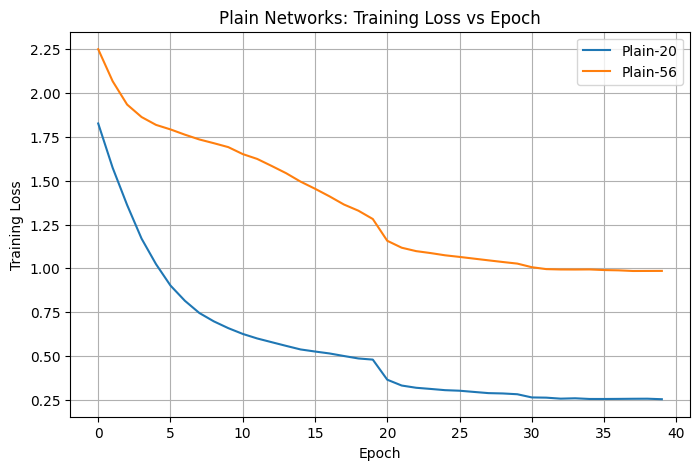

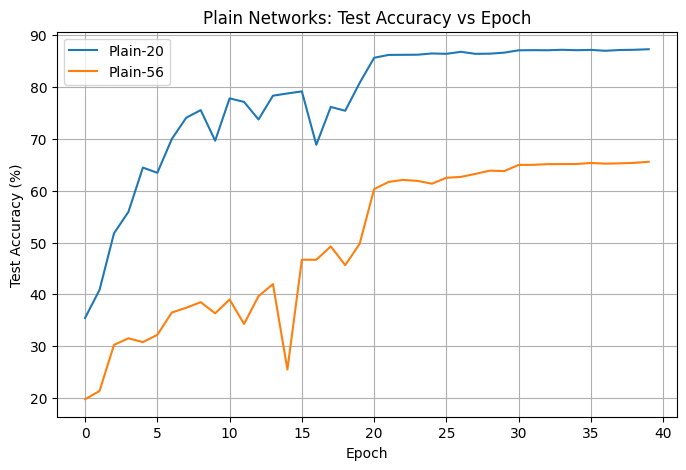

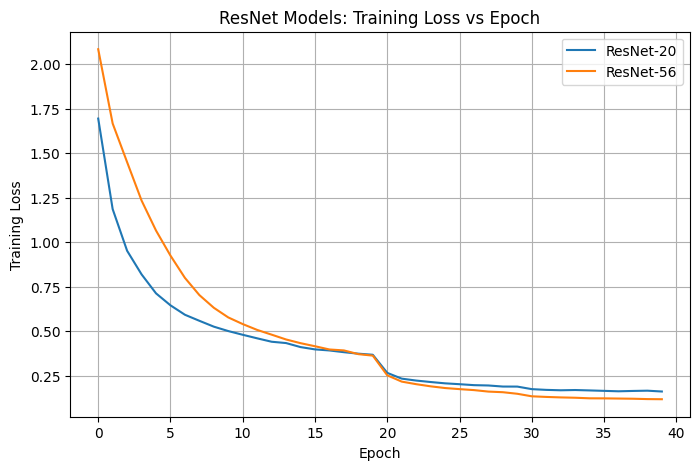

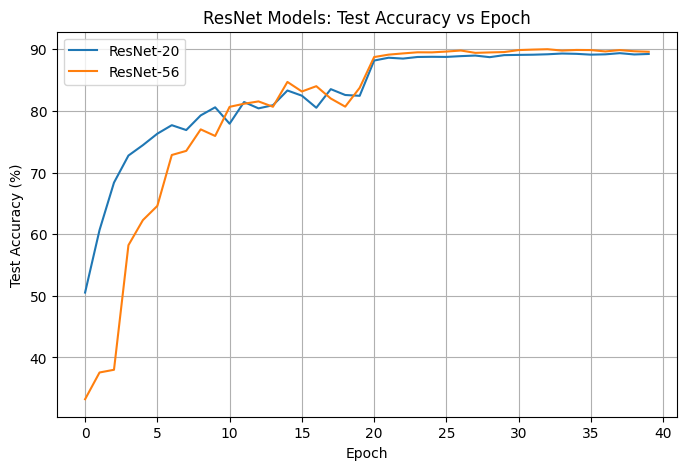

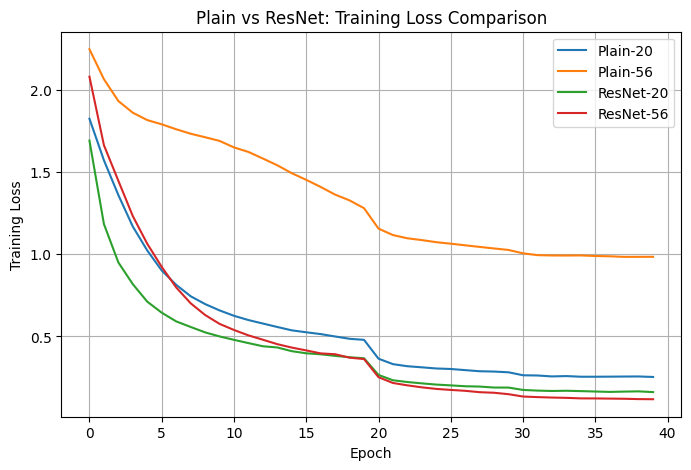

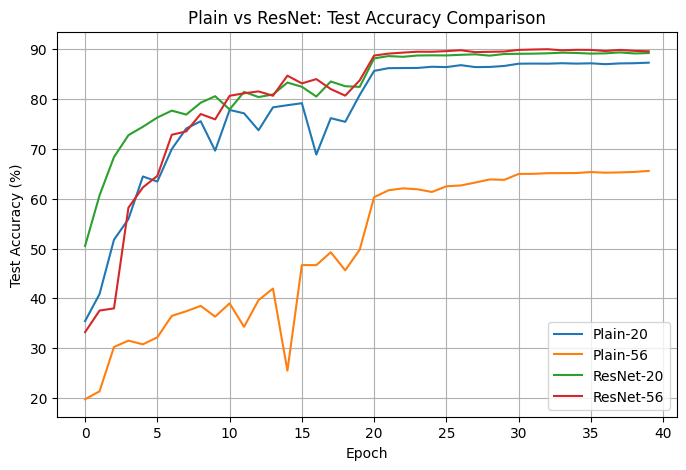

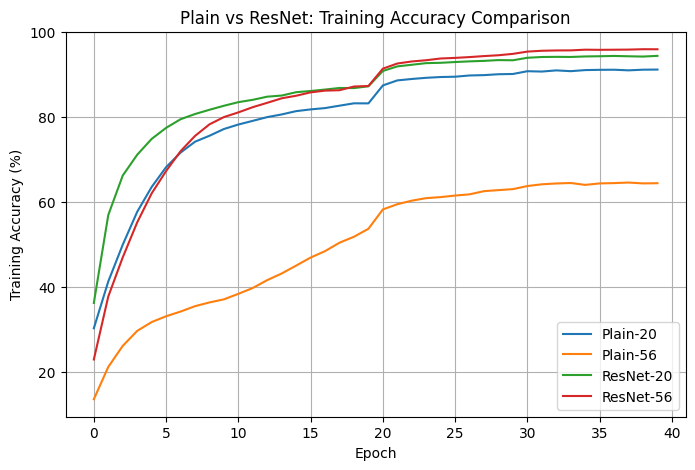

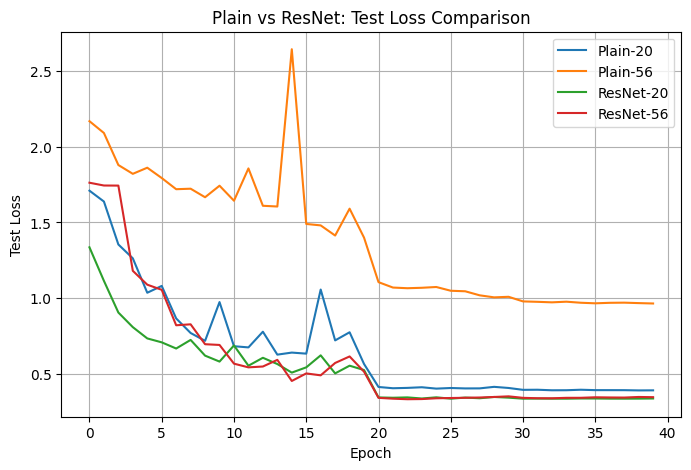

In [8]:
# Helper function to plot a specific metric over epochs for all models

def plot_metric(histories, metric_key, title, ylabel):
    plt.figure(figsize=(8, 5))

    for label, history in histories.items():
        plt.plot(history[metric_key], label=label)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

plain_histories = {
    "Plain-20": history_plain20,
    "Plain-56": history_plain56,
}

resnet_histories = {
    "ResNet-20": history_resnet20,
    "ResNet-56": history_resnet56,
}

all_histories = {
    "Plain-20": history_plain20,
    "Plain-56": history_plain56,
    "ResNet-20": history_resnet20,
    "ResNet-56": history_resnet56,
}

plot_metric(
    plain_histories,
    metric_key="train_loss",
    title="Plain Networks: Training Loss vs Epoch",
    ylabel="Training Loss",
)

plot_metric(
    plain_histories,
    metric_key="test_acc",
    title="Plain Networks: Test Accuracy vs Epoch",
    ylabel="Test Accuracy (%)",
)

plot_metric(
    resnet_histories,
    metric_key="train_loss",
    title="ResNet Models: Training Loss vs Epoch",
    ylabel="Training Loss",
)

plot_metric(
    resnet_histories,
    metric_key="test_acc",
    title="ResNet Models: Test Accuracy vs Epoch",
    ylabel="Test Accuracy (%)",
)

plot_metric(
    all_histories,
    metric_key="train_loss",
    title="Plain vs ResNet: Training Loss Comparison",
    ylabel="Training Loss",
)

plot_metric(
    all_histories,
    metric_key="test_acc",
    title="Plain vs ResNet: Test Accuracy Comparison",
    ylabel="Test Accuracy (%)",
)

plot_metric(
    all_histories,
    metric_key="train_acc",
    title="Plain vs ResNet: Training Accuracy Comparison",
    ylabel="Training Accuracy (%)",
)

plot_metric(
    all_histories,
    metric_key="test_loss",
    title="Plain vs ResNet: Test Loss Comparison",
    ylabel="Test Loss",
)

In [9]:
def summarize_final_metrics(histories):
    summary = []
    for label, history in histories.items():
        summary.append(
            {
                "Model": label,
                "Final Train Loss": history["train_loss"][-1],
                "Final Train Acc": history["train_acc"][-1],
                "Final Test Loss": history["test_loss"][-1],
                "Final Test Acc": history["test_acc"][-1],
            }
        )
    return summary

summary_df = pd.DataFrame(summarize_final_metrics(all_histories))
print("\nFinal Metrics Summary:")
print(summary_df)


Final Metrics Summary:
       Model  Final Train Loss  Final Train Acc  Final Test Loss  \
0   Plain-20          0.252737           91.224         0.389133   
1   Plain-56          0.985269           64.486         0.963780   
2  ResNet-20          0.160320           94.448         0.335274   
3  ResNet-56          0.116990           95.996         0.343937   

   Final Test Acc  
0           87.32  
1           65.59  
2           89.25  
3           89.61  
